# Categorization of precipitation for predicting combined sewer overflows. Application to the City of Montréal.

Jonathan Jalbert$^{1}$, Claudie Ratté-Fortin$^{2}$,  Jean-Baptiste Burnet$^1$ & Émilie Papillon$^3$

$^1$Polytechnique Montréal\
$^2$HEC Montréal\
$^3$City of Montréal

May 24, 2024

This program goes along with the paper of [Jalbert *et al.* (2024)](https://www.sciencedirect.com/science/article/pii/S0022169424007285). This program provides the code to reproduce the results.

The notebook runs with a Julia 1.10 kernel and uses these package versions:
- CSV v0.10.14
- DataFrames v1.6.1
- DecisionTree v0.12.4
- Gadfly v1.4.0
- MLBase v0.9.2


### Reference

Jalbert, J., Ratté-Fortin, C., Burnet, J.-B. and Émilie Papillon (2024). Categorization of precipitation for predicting combined sewer overflows. Application to the City of Montréal. *Journal of Hydrology*, 131333.


In [1]:
using CSV, DataFrames, Dates
using DecisionTree, MLBase
using Gadfly

## Data loading

### CSO loading

In [2]:
cso = CSV.read("cso_raw.csv", DataFrame)

filter!(row -> month(row.Date) in 5:10, cso)
# filter!(row -> year(row.Date) in 2013:2019, cso) # Exactement la même catégorisation sur l'ensemble d'entraînement

# Removing the CSO not caused by precipitation 
filter!(row -> isequal(row.Code, missing) | isequal(row.Code, "P") , cso)

# Removing the line where the sites are not monitored
filter!(row -> !(isequal(row.Monitored, "NS")), cso)

# Removing the line with missing data
dropmissing!(cso, :Duration);

# Outlets of interest for the Verdun Beach

outlets = ["4370-03D",
    "4370-05D",
    "4430-04D",
    "4430-01D",
    "4430-02D",
    "4420-01D",
    "4795-01D",
    "4400-02D",
    "4400-01D"] 

filter!(row-> row.Site in outlets, cso)

Row,Site,Date,Duration,Code,Monitored,Comment
,String15,Date,Float64,String3?,String3?,String?
1,4370-03D,2013-05-01,0.0,missing,missing,missing
2,4370-03D,2013-05-02,0.0,missing,missing,missing
3,4370-03D,2013-05-03,0.0,missing,missing,missing
4,4370-03D,2013-05-04,0.0,missing,missing,missing
5,4370-03D,2013-05-05,0.0,missing,missing,missing
6,4370-03D,2013-05-06,0.0,missing,missing,missing
7,4370-03D,2013-05-07,0.0,missing,missing,missing
8,4370-03D,2013-05-08,0.0,missing,missing,missing
9,4370-03D,2013-05-09,0.0,missing,missing,missing


### CSO combination

In [3]:
cso.Overflow = Int.(cso.Duration .> 12.0)

overflow = combine(groupby(cso, :Date), :Overflow => sum => :Number)

sort(combine(groupby(overflow, :Number), nrow => :Occurrence), :Number)

Row,Number,Occurrence
,Int64,Int64
1,0,1259
2,1,116
3,2,38
4,3,17
5,4,12
6,5,12
7,6,9
8,7,4
9,8,4


In [4]:
# Adding a column indicating if at least an overflow occurred.

overflow[:,:Overflow] = string.(Int.( overflow.Number .> 0))

first(overflow, 10)

Row,Date,Number,Overflow
,Date,Int64,String
1,2013-05-01,0,0
2,2013-05-02,0,0
3,2013-05-03,0,0
4,2013-05-04,0,0
5,2013-05-05,0,0
6,2013-05-06,0,0
7,2013-05-07,0,0
8,2013-05-08,0,0
9,2013-05-09,0,0


### Precipitation loading

In [5]:
pcp = CSV.read("Montreal-Trudeau_15min_precipitations.csv", DataFrame)
first(pcp, 5)

Row,Date,d15min,d30min,d45min,d1h,d2h,d3h,d4h,d6h,d8h,d12h,d24h
,Date,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2013-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2013-05-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2013-05-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2013-05-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2013-05-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Extracting feature names (precipitation durations)

varnames = names(pcp)[2:end]
varsymbols = Symbol.(varnames);

In [7]:
# Transforming precipitation in mm.

for v in varsymbols
    pcp[:,v] = pcp[:,v]/10
end

In [8]:
# Joining CSO and precipitation into a single DataFrame

data = innerjoin(overflow, pcp, on = :Date)
first(data,5)

Row,Date,Number,Overflow,d15min,d30min,d45min,d1h,d2h,d3h,d4h,d6h,d8h,d12h,d24h
,Date,Int64,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2013-05-01,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2013-05-02,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2013-05-03,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2013-05-04,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2013-05-05,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Removing the days without precipitation

filter!(row -> row[:d24h]>0, data)
first(data, 5)

Row,Date,Number,Overflow,d15min,d30min,d45min,d1h,d2h,d3h,d4h,d6h,d8h,d12h,d24h
,Date,Int64,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2013-05-09,0,0,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2
2,2013-05-10,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2
3,2013-05-11,0,0,2.3,3.5,4.5,5.7,9.8,11.5,12.4,12.4,12.6,13.9,14.1
4,2013-05-12,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.2,0.2,14.1
5,2013-05-15,0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Data split into a training and a test sets

In [10]:
train = filter(row -> year(row.Date) < 2020, data);
test = filter(row -> year(row.Date) == 2020, data);

## Decision tree

### Fit on the training set

In [11]:
model = DecisionTreeClassifier(max_depth=2)

features = Matrix(train[:, varsymbols])

labels = train.Overflow

tree = DecisionTree.fit!(model, features, labels)

ptree = prune_tree(tree.root, .8)

SEUIL_CAT1=0.9; SEUIL_CAT3=0.8

print_tree(ptree)

Feature 4 < 2.95 ?
├─ 0 : 517/554
└─ Feature 7 < 13.35 ?
    ├─ 1 : 75/137
    └─ 1 : 60/65


### Extract the feature of the first split

In [12]:
feature1 = varnames[ptree.node.featid]
# feature2 = varnames[tree.root.left.featid]

"d1h"

### Extract the threshold of the first split

In [13]:
u1 = ptree.node.featval

2.95

### Extract the feature of the second split

In [14]:
feature2 = varnames[ptree.node.right.featid]

"d4h"

### Extract the threshold of the second split

In [15]:
u2 = ptree.node.right.featval

13.35

### Classification on the training set

In [16]:
df = DataFrame(Category=String[], Occurrence=Int64[], Overflow=String[])

# Category 1
push!(df, ["1", count(ptree.node.left.values.=="0"), "0"])
push!(df, ["1", count(ptree.node.left.values.=="1"), "1"])

# Category 2
push!(df, ["2", count(ptree.node.right.left.values.=="0"), "0"])
push!(df, ["2", count(ptree.node.right.left.values.=="1"), "1"])

# # Category 3
push!(df, ["3", count(ptree.node.right.right.values.=="0"), "0"])
push!(df, ["3", count(ptree.node.right.right.values.=="1"), "1"])

Row,Category,Occurrence,Overflow
,String,Int64,String
1,1,517,0
2,1,37,1
3,2,62,0
4,2,75,1
5,3,5,0
6,3,60,1


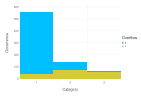

In [17]:
fig = plot(df, x=:Category, y=:Occurrence, color=:Overflow, Geom.bar(position=:stack))

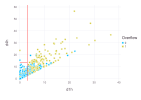

In [18]:
points = layer(data, x=feature1, y=feature2, color=:Overflow, Geom.point)
categories = layer(x=[0, u1], y=[u2, u2], Geom.line,
    xintercept=[u1], Geom.vline,
    Theme(default_color="red"))

fig = plot(categories, points, Guide.xlabel(feature1), Guide.ylabel(feature2))

### Train set precipitation classification

In [19]:
c = String[]

for r in eachrow(train)
    
    if r[feature1]< u1
        push!(c, "1")
    elseif r[feature2] < u2
        push!(c, "2")
    else
        push!(c, "3")
    end
end

train.Category = c;

#### Number of outlets overflowing for Category 1 precipitation

In [20]:
df = filter(row -> row.Category=="1", train)
df2 = sort(combine(groupby(df, :Number), nrow => :Occurrence), :Number)

Row,Number,Occurrence
,Int64,Int64
1,0,517
2,1,33
3,2,4


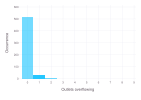

In [21]:
a = repeat([0.55, 0.85], outer=10)

fig = plot(df2, x=:Number, y=:Occurrence, Geom.bar, alpha=[a;a], 
    Coord.cartesian(xmin=-.50), Guide.xticks(ticks=0:9),
    Guide.xlabel("Outlets overflowing"))

#### Number of outlets overflowing for Category 2 precipitation

In [22]:
df = filter(row -> row.Category=="2", train)
df2 = sort(combine(groupby(df, :Number), nrow => :Occurrence), :Number)

Row,Number,Occurrence
,Int64,Int64
1,0,62
2,1,44
3,2,13
4,3,7
5,4,4
6,5,5
7,7,2


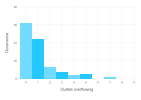

In [23]:
fig = plot(df2, x=:Number, y=:Occurrence, Geom.bar, alpha=[a;a], 
    Coord.cartesian(xmin=-.50), Guide.xticks(ticks=0:9),
    Guide.xlabel("Outlets overflowing"))

#### Number of outlets overflowing for Category 3 precipitation

In [24]:
df = filter(row -> row.Category=="3", train)
df2 = sort(combine(groupby(df, :Number), nrow => :Occurrence), :Number)

Row,Number,Occurrence
,Int64,Int64
1,0,5
2,1,14
3,2,13
4,3,7
5,4,7
6,5,5
7,6,8
8,7,2
9,8,3


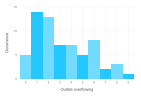

In [25]:
fig = plot(df2, x=:Number, y=:Occurrence, Geom.bar, alpha=[a;a], 
    Coord.cartesian(xmin=-.50), Guide.xticks(ticks=0:9),
    Guide.xlabel("Outlets overflowing"))

## CSO prediction on the test set

### Test set precipitation classification

In [26]:
c = String[]

for r in eachrow(test)
   if r[feature1]< u1
        push!(c, "1")
    elseif r[feature2] < u2
        push!(c, "2")
    else
        push!(c, "3")
    end
end

test.Category=c;

### CSO prediction as function of precipitation category

In [27]:
ŷ = String[]

for r in eachrow(test)
    if r[:Category] == "1"
        push!(ŷ, "0")
    else
        push!(ŷ, "1")
    end
end

test.Prediction = ŷ

first(test,5)

Row,Date,Number,Overflow,d15min,d30min,d45min,d1h,d2h,d3h,d4h,d6h,d8h,d12h,d24h,Category,Prediction
,Date,Int64,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,String
1,2020-05-01,0,0,0.4,0.5,0.8,0.8,0.8,0.8,0.8,0.8,1.3,1.3,7.6,1,0
2,2020-05-02,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3,1,0
3,2020-05-03,0,0,0.8,1.4,1.4,1.9,1.9,1.9,1.9,1.9,2.1,2.1,2.3,1,0
4,2020-05-04,0,0,0.0,0.2,0.2,0.2,0.2,0.2,0.2,0.2,2.1,2.1,2.3,1,0
5,2020-05-08,0,0,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,1,0


In [28]:
# Precipitation category occurences on the test set

combine(groupby(test, :Category), :Date => length => :n)

Row,Category,n
,String,Int64
1,1,74
2,3,10
3,2,17


In [29]:
# Confusion matrix computation

r = roc(parse.(Int, test.Overflow), parse.(Int, test.Prediction))

ROCNums{Int64}
  p = 24
  n = 77
  tp = 20
  tn = 70
  fp = 7
  fn = 4


In [30]:
f1score(r)

0.7843137254901961

In [31]:
# Sensitivity
recall(r)

0.8333333333333334

In [32]:
# Specificity
true_negative_rate(r)

0.9090909090909091